# Análisis partidas personales chess.com

El propósito del trabajo es analizar el historial de mis partidas de ajedrez en la plataforma chess.com, con el objetivo de identificar mis puntos fuertes y mis debilidades y poder tanto potenciar los primeros como centrarme en solucionar los segundos.

La plataforma chess.com expone los datos de todas las partidas jugadas a través de la API oficial: https://www.chess.com/news/view/published-data-api

Para este análisis he extraído los datos pertenecientes a mi usuario mediante el script extraccion_partidas.py y lo he guardado directamente con el nombre mis_partidas_rapid.json

La búsqueda se ha filtrado solamente a las partidas rápidas (10-30 min), que son las que juego principalmente.

In [59]:
import json

# Leemos el json con mis partidas rápidas 
with open("mis_partidas_rapid.json", "r", encoding="utf-8") as f:
    data = json.load(f)

In [60]:
import pandas as pd

# Convertimos la lista de partidas en un DataFrame expandiendo los diccionarios anidados
df = pd.json_normalize(data)

In [61]:
df.head(3)

,url,pgn,time_control,end_time,rated,tcn,uuid,initial_setup,fen,time_class,...,white.@id,white.username,white.uuid,black.rating,black.result,black.@id,black.username,black.uuid,accuracies.white,accuracies.black
0,https://www.chess.com/game/live/6532080288,"[Event ""Live Chess""]\n[Site ""Chess.com""]\n[Dat...",1800,1613125783,True,mC0SfAYIgv3VoE2MltWOiy!TbsTEhgEKvK5QKvQzpxZJAr...,f2aa50c2-6d19-11eb-9f08-0069e4010001,rnbqkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR w ...,4k3/4Q3/3B4/8/P7/1P6/2P2P2/4K3 b - -,rapid,...,https://api.chess.com/pub/player/pablo07as,Pablo07as,e34dc59a-6d19-11eb-8685-edbf2922a2c4,444,checkmated,https://api.chess.com/pub/player/javi_18,javi_18,a0cb29ee-6bd2-11eb-b6aa-3b3230cc1c70,NaN,NaN
1,https://www.chess.com/game/live/6538262049,"[Event ""Live Chess""]\n[Site ""Chess.com""]\n[Dat...",1800,1613166475,True,mCWGiyXPbs4OgvZJCJYIaq0SpFOWoEWZhxZJsJSJFN3Vdm...,cdf81f81-6d7a-11eb-9f08-0069e4010001,rnbqkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR w ...,7N/8/7Q/3k3P/QP6/4R3/1B1P1P2/4KB2 b - -,rapid,...,https://api.chess.com/pub/player/pablo07as,Pablo07as,e34dc59a-6d19-11eb-8685-edbf2922a2c4,826,stalemate,https://api.chess.com/pub/player/danigarcia756,Danigarcia756,7a08443e-6d78-11eb-98ab-d7168c00282c,NaN,NaN
2,https://www.chess.com/game/live/6563684201,"[Event ""Live Chess""]\n[Site ""Chess.com""]\n[Dat...",1800,1613386326,True,kAYIjr5Omu0Sbs!TcjOziqzQow3Nfo?VgvVUsHUwpwWOHs...,99f3ffd2-6f7a-11eb-9f08-0069e4010001,rnbqkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR w ...,2bk4/1p2Q3/1q1p1Bp1/p1p5/2P5/PP2P1P1/3P4/R4RK1...,rapid,...,https://api.chess.com/pub/player/bobie010,Bobie010,162b4044-6efc-11eb-9ea5-557ccf684c4e,753,checkmated,https://api.chess.com/pub/player/pablo07as,Pablo07as,e34dc59a-6d19-11eb-8685-edbf2922a2c4,77.39,34.42


In [62]:
df['pgn'][0]

'[Event "Live Chess"]\n[Site "Chess.com"]\n[Date "2021.02.12"]\n[Round "-"]\n[White "Pablo07as"]\n[Black "javi_18"]\n[Result "1-0"]\n[CurrentPosition "4k3/4Q3/3B4/8/P7/1P6/2P2P2/4K3 b - -"]\n[Timezone "UTC"]\n[ECO "B20"]\n[ECOUrl "https://www.chess.com/openings/Sicilian-Defense-Bowdler-Attack-2...e6"]\n[UTCDate "2021.02.12"]\n[UTCTime "10:06:40"]\n[WhiteElo "875"]\n[BlackElo "444"]\n[TimeControl "1800"]\n[Termination "Pablo07as won by checkmate"]\n[StartTime "10:06:40"]\n[EndDate "2021.02.12"]\n[EndTime "10:29:43"]\n[Link "https://www.chess.com/game/live/6532080288"]\n\n1. e4 {[%clk 0:30:00]} 1... e6 {[%clk 0:30:00]} 2. Bc4 {[%clk 0:29:41.2]} 2... c5 {[%clk 0:29:50.3]} 3. Nf3 {[%clk 0:29:36.3]} 3... h6 {[%clk 0:29:46.5]} 4. g4 {[%clk 0:29:30.4]} 4... g5 {[%clk 0:29:43.1]} 5. d3 {[%clk 0:29:17.6]} 5... a6 {[%clk 0:29:30.8]} 6. a4 {[%clk 0:29:15.1]} 6... Nf6 {[%clk 0:29:13.7]} 7. Nc3 {[%clk 0:29:02.5]} 7... Nxg4 {[%clk 0:29:08.8]} 8. Rg1 {[%clk 0:28:40.2]} 8... Ne5 {[%clk 0:28:59.6]} 9. 

Como primer análisis me gustaría ver en que momentos de la semana obtengo mejores resultados y identificar posibles consecuencias de cansancio mental y ver cuando me interesa más jugar.

Para ello vamos ha extraer la fecha y hora de las partidas y agruparlas en intervalos de 2 horas para la visualización correspondiente.

In [63]:
# Extraemos la fecha de cada partida en horario de Madrid
df['fecha_hora'] = pd.to_datetime(df['end_time'], unit='s') 
df['fecha_hora'] = df['fecha_hora'].dt.tz_localize('UTC').dt.tz_convert('Europe/Madrid')

# Creamos columnas con la hora y el día de la semana
df['hora_del_dia'] = df['fecha_hora'].dt.hour  
df['dia_semana'] = df['fecha_hora'].dt.day_name()  

# Como hemos dicho, asignamos etiquetas en intervalos de dos horas 
def etiqueta_rango_2h(hora):
    inicio = (hora // 2) * 2
    # Formateamos para que quede bonito: "14:00-15:59"
    return f"{inicio:02d}:00-{inicio+1:02d}:59"

# Creamos la nueva columna de franjas horarias
df['rango_2h'] = df['hora_del_dia'].apply(etiqueta_rango_2h)

# Le decimos a Pandas el orden lógico de los días, si no, los pondrá alfabéticamente
dias_orden = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df['dia_semana'] = pd.Categorical(df['dia_semana'], categories=dias_orden, ordered=True)

Ahora vamos a ver cuando ganan las blancas y cuando las negras, para ello mapeamos los posibles resultados de la partida (victoria: 1, empate: 0, derrota:-1):

In [64]:
df['white.result'].value_counts()

white.result
win                   1097
resigned               514
checkmated             363
abandoned               78
timeout                 38
repetition              24
stalemate               22
insufficient            16
agreed                   5
timevsinsufficient       3
Name: count, dtype: int64

In [65]:
df['black.result'].value_counts()

black.result
win                   993
resigned              536
checkmated            468
abandoned              55
timeout                38
repetition             24
stalemate              22
insufficient           16
agreed                  5
timevsinsufficient      3
Name: count, dtype: int64

In [66]:
df['resultado_blancas'] = df['white.result'].map({
    'win': 1,
    'resigned': -1,
    'checkmated': -1,
    'abandoned': -1,
    'timeout': -1,
    'repetition':0,
    'stalemate': 0,
    'insufficient': 0,
    'agreed': 0,
    'timevsinsufficient': 0
    })

df['resultado_negras'] = df['black.result'].map({
    'win': 1,
    'resigned': -1,
    'checkmated': -1,
    'abandoned': -1,
    'timeout': -1,
    'repetition':0,
    'stalemate': 0,
    'insufficient': 0,
    'agreed': 0,
    'timevsinsufficient': 0
    })

Por último, identifiquemos cuando juego con negras y cuando con blancas, y en consecuencia mi resultado en la partida.

In [67]:
import pandas as pd
import numpy as np

usuario = "pablo07as"

def resultado(fila):
    # Comprobamos si jugaba con blancas
    if fila['white.username'].lower() == usuario:
        if fila['resultado_blancas'] == 1:
            return 1
        elif fila['resultado_blancas'] == -1:
            return -1
        else:
            return 0
    # Comprobamos si jugaba con negras
    elif fila['black.username'].lower() == usuario:
        if fila['resultado_negras'] == 1:
            return 1
        elif fila['resultado_negras'] == -1:
            return -1
        else:
            return 0
    else:
        return 0

def mi_color(fila):
    if fila['white.username'].lower() == usuario:
        return 'blancas'
    elif fila['black.username'].lower() == usuario:
        return 'negras'
    else:
        return 'desconocido'

# Obtenemos la columna de color y victoria usando las funciones definidas
df['mi_color'] = df.apply(mi_color, axis=1)
df['resultado'] = df.apply(resultado, axis=1)

Para representar el rendimiento por franja horaria vamos a usar un heatmap con el porcentaje de victoria. Para ello vamos a ignorar los empates.

In [68]:
# Descartamos los empates pues no aporta información sobre el rendimiento
df_decisivo = df[df['resultado'] != 0].copy()

# Dejamos las derrotas como ceros para calcular el porcentaje con mean()
df_decisivo['victoria'] = df_decisivo['resultado'].map({1: 1, -1: 0})

# Agrupamos por día de la semana y franja horaria, calculando la media de victorias y el número de partidas
df_semanal = df.groupby(['dia_semana', 'rango_2h'], observed=False)['victoria'].agg(['mean', 'count']).reset_index()


# Definimos un umbral mínimo de partidas por rango para considerar el porcentaje de victorias como representativo
UMBRAL_PARTIDAS = 30

# np.where funciona como un "IF" de Excel: si hay 5 o más partidas, guardamos el porcentaje. Si no, ponemos "NaN" (nulo).
df_semanal['porc_victorias'] = np.where(
    df_semanal['count'] >= UMBRAL_PARTIDAS, 
    df_semanal['mean'], 
    np.nan
)
# Creamos la tabla dinámica: cruza días (filas) con horas (columnas) y calcula la media de victorias
mapa_datos = df_semanal.pivot(
    index='dia_semana', 
    columns='rango_2h', 
    values='porc_victorias'
) * 100 # Multiplicamos por 100 para que se lea como porcentaje (ej. 55%)

KeyError: 'Column not found: victoria'

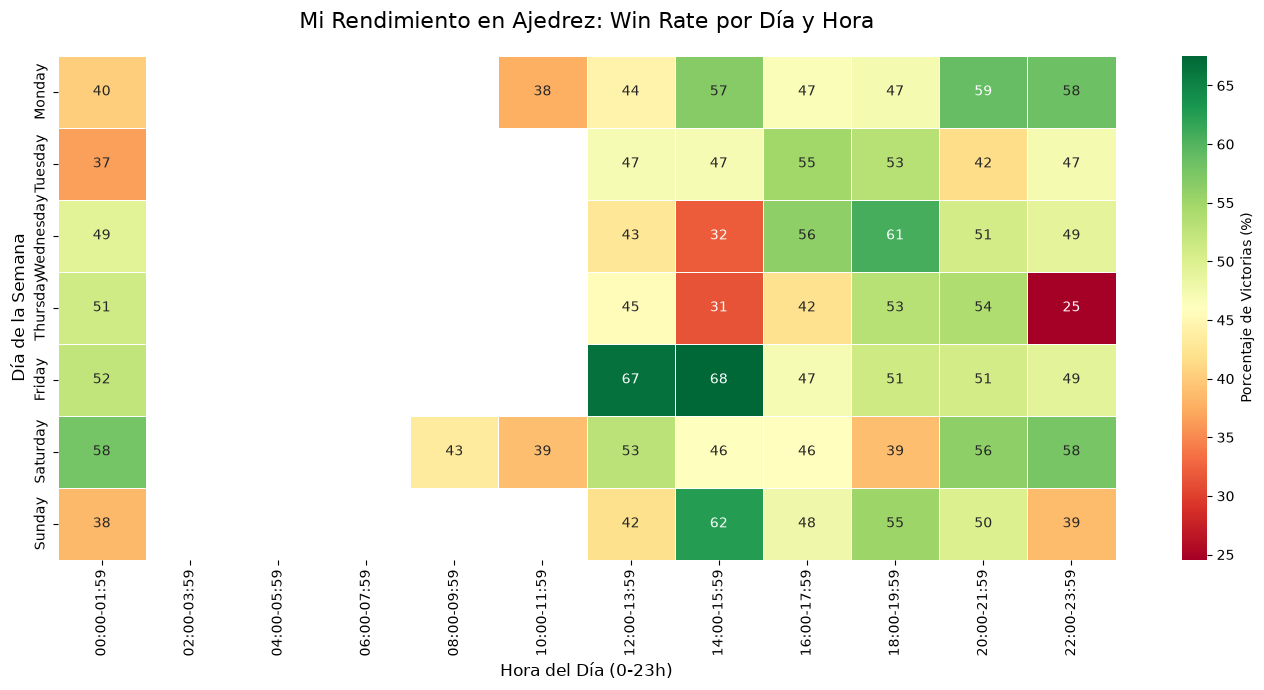

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Configuramos el tamaño del lienzo (ancho, alto)
plt.figure(figsize=(14, 7))

# Pintamos el Heatmap
sns.heatmap(
    mapa_datos, 
    cmap="RdYlGn", 
    annot=True, 
    fmt=".0f", 
    linewidths=0.5,
    cbar_kws={'label': 'Porcentaje de Victorias (%)'}
)

# Añadimos títulos y etiquetas 
plt.title('Mi Rendimiento en Ajedrez: Win Rate por Día y Hora', fontsize=16, pad=20)
plt.xlabel('Hora del Día (0-23h)', fontsize=12)
plt.ylabel('Día de la Semana', fontsize=12)

# Muestra el gráfico
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import plotly.express as px
import re

def extraer_apertura(pgn_texto):
    # Usamos una expresión regular para buscar el texto después de 'openings/'
    match = re.search(r'\[ECOUrl "https://www.chess.com/openings/([^"]+)"\]', str(pgn_texto))
    if match:
        # Reemplazamos los guiones por espacios para que el nombre se lea bien
        apertura = match.group(1).replace('-', ' ')
        return apertura
    return "Desconocida"

# Creamos la nueva columna leyendo el interior del PGN
df['apertura'] = df['pgn'].apply(extraer_apertura)

In [ ]:
# Calculamos el porcentaje de victorias por color para luego compararlas en relación a al media
porc_victoria_blancas = df[df['mi_color'] == 'blancas']['victoria'].mean() * 100
porc_victoria_negras = df[df['mi_color'] == 'negras']['victoria'].mean() * 100

analisis = df.groupby(['mi_color', 'apertura']).agg(
    volumen_partidas=('victoria', 'count'),
    porcentaje_win=('victoria', lambda x: x.mean() * 100)
).reset_index()

# Filtramos las que tienen menos de 5 partidas y redondeamos
analisis = analisis[analisis['volumen_partidas'] >= 25]
analisis['porcentaje_win'] = analisis['porcentaje_win'].round(1)

In [ ]:
df_blancas = analisis[analisis['mi_color'] == 'blancas']
df_negras = analisis[analisis['mi_color'] == 'negras']

In [ ]:
paleta_dura = ['#8B0000', "#C85858", '#66FF66', '#006400']


fig_blancas = px.treemap(
    df_blancas, 
    path=[px.Constant("Mis Sistemas de Ataque (Blancas)"), 'apertura'], 
    values='volumen_partidas',                              
    color='porcentaje_win',                                 
    color_continuous_scale=paleta_dura,                        
    range_color=[porc_victoria_blancas-15, porc_victoria_blancas+15],                     
    title='Jugando con Blancas: Mis Mejores y Peores Aperturas'
)

fig_blancas.update_traces(
    hovertemplate='<b>%{label}</b><br>Partidas: %{value}<br>Win Rate: %{color}%<extra></extra>',
    textinfo="label+value" 
)
fig_blancas.update_layout(margin=dict(t=50, l=25, r=25, b=25))


fig_negras = px.treemap(
    df_negras, 
    path=[px.Constant("Mis Defensas (Negras)"), 'apertura'], 
    values='volumen_partidas',                              
    color='porcentaje_win',                                 
    color_continuous_scale=paleta_dura,                        
    range_color=[porc_victoria_negras-15, porc_victoria_negras+15],                     
    title='Jugando con Negras: Mis Mejores y Peores Defensas'
)

fig_negras.update_traces(
    hovertemplate='<b>%{label}</b><br>Partidas: %{value}<br>Win Rate: %{color}%<extra></extra>',
    textinfo="label+value" 
)
fig_negras.update_layout(margin=dict(t=50, l=25, r=25, b=25))

fig_blancas.show()
fig_negras.show()

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import re


def contar_movimientos(pgn_texto):
    # Buscamos todos los números seguidos de un punto 
    coincidencias = re.findall(r'(\d+)\.', str(pgn_texto))
    if coincidencias:
        # El último número de la lista es el movimiento final de la partida
        return int(coincidencias[-1])
    return 0

# Creamos la nueva columna
df['num_movimientos'] = df['pgn'].apply(contar_movimientos)

In [ ]:
# Filtramos las partidas "abortadas" (menos de 3 movimientos) para que no ensucien
df_movimientos = df[df['num_movimientos'] >= 3].copy()

# Creamos una columna de texto limpio para la leyenda
df_movimientos['Resultado'] = df_movimientos['victoria'].map({1: 'Victoria', 0: 'Derrota o Empate'})

In [ ]:
plt.figure(figsize=(12, 6))

# El KDE Plot dibuja las "montañas" de densidad
sns.kdeplot(
    data=df_analisis, 
    x='num_movimientos', 
    hue='Resultado', 
    fill=True,             # Rellena de color el interior de las montañas
    common_norm=False,     # ¡CLAVE! Hace que las dos montañas sean del mismo tamaño visual aunque ganes más que pierdas
    palette={'Victoria': '#2ca02c', 'Derrota o Empate': '#d62728'}, # Verde y Rojo clásico
    alpha=0.5,             # Le da un toque translúcido para ver dónde se solapan
    linewidth=2
)

# Añadimos líneas verticales para marcar la MEDIA exacta de movimientos
media_win = df_analisis[df_analisis['victoria'] == 1]['num_movimientos'].mean()
media_loss = df_analisis[df_analisis['victoria'] == 0]['num_movimientos'].mean()

plt.axvline(media_win, color='#2ca02c', linestyle='--', alpha=0.8)
plt.axvline(media_loss, color='#d62728', linestyle='--', alpha=0.8)

# Añadimos texto para explicar las líneas punteadas
plt.text(media_win + 1.5, plt.ylim()[1]*0.9, f'Media Victorias: {media_win:.0f}', color='#006400', fontweight='bold')
plt.text(media_loss + 1.5, plt.ylim()[1]*0.8, f'Media Derrotas: {media_loss:.0f}', color='#8B0000', fontweight='bold')

# Detalles estéticos finales
plt.title('Mi Perfil de Supervivencia: ¿En qué momento se deciden mis partidas?', fontsize=16, pad=20)
plt.xlabel('Número Total de Movimientos', fontsize=12)
plt.ylabel('Densidad (Frecuencia)', fontsize=12)

# Ajustamos los límites para que empiece en la jugada 0
plt.xlim(left=0)
plt.tight_layout()

plt.show()